# Traitement des valeurs manquantes — compléments

## Pourquoi un chapitre « compléments » ?

Dans le notebook **basique** (`05-feature-engineering-basics/02-feature-engineering-basics`), on avait vu la méthode « universelle » :

- **Numérique manquant** → imputer par la **médiane**.
- **Catégoriel manquant** → imputer par le **mode** (valeur la plus fréquente).

C'est **simple, rapide et robuste**. Pour beaucoup de problèmes réels, c'est **suffisant**. Mais ce n'est pas toujours la meilleure approche — et ce notebook explique **quand** et **comment** faire mieux.

> **L'analogie à garder en tête :** quand un médecin remplit un formulaire et qu'il ne connaît pas le poids exact du patient, il peut soit :
>
> 1. **Mettre le poids moyen** de la population (solution paresseuse mais simple).
> 2. **Estimer à partir du contexte** : un homme de 1m85 et 35 ans sportif pèse probablement plus qu'une femme de 1m55 et 70 ans. (solution intelligente mais demande plus d'information).
>
> La deuxième approche est **toujours meilleure quand elle est possible**. Ce notebook montre comment l'appliquer au Titanic.

![feature engineering](../../images/feature-engineering-process.png)

## Les trois types de valeurs manquantes (cadre MCAR / MAR / MNAR)

Avant de traiter les NaN, il faut comprendre **pourquoi ils manquent**. Les statisticiens distinguent trois cas, aux conséquences très différentes :

### MCAR — *Missing Completely At Random*

**La valeur manque de façon purement aléatoire, sans lien avec quoi que ce soit.** Exemple : un capteur de température qui plante au hasard une fois par mois.

- **Conséquence :** imputer par la médiane/mode est OK, c'est la situation la plus simple.
- **C'est rarement le cas en vrai.**

### MAR — *Missing At Random*

**La valeur manque, mais la probabilité qu'elle manque dépend d'autres variables observées** (pas de la valeur manquante elle-même).

Exemple : *« les passagers en 3ème classe ont plus souvent un âge manquant parce qu'ils ont été enregistrés plus rapidement »*. L'absence d'âge est liée à la classe — **pas à l'âge réel**.

- **Conséquence :** on peut **imputer intelligemment** en utilisant les autres variables pour estimer la valeur manquante.
- **C'est le cas le plus fréquent en pratique.** C'est sur ce cas qu'on va travailler dans ce notebook.

### MNAR — *Missing Not At Random*

**L'absence de valeur dépend de la valeur elle-même.** Exemple : les gens à très hauts revenus refusent plus souvent de déclarer leurs revenus. L'absence est liée à la valeur manquante.

- **Conséquence :** c'est le cas **le plus difficile**. Aucune imputation n'est parfaite, et toute analyse est potentiellement biaisée. **Dans ce cas, la présence du NaN est elle-même une information** — il faut souvent ajouter une variable indicatrice `was_missing` pour permettre au modèle de l'exploiter.

> **🎯 À retenir :** *avant* d'imputer, toujours se poser la question *« pourquoi cette valeur manque-t-elle ? »*. La réponse guide le choix de la méthode — et détermine si les conclusions du modèle seront fiables.

## Le plan de ce notebook

1. **Split stratifié** pour préserver l'équilibre des classes.
2. **Imputation intelligente** de `age`, `fare`, `embarked` en utilisant les **corrélations** entre variables (approche MAR).
3. **Comparaison** avec l'approche naïve du chapitre précédent.

Le principe général : **exploiter les relations entre variables** pour donner aux imputations un sens qui se rapproche de la réalité.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
titanic = fetch_openml("titanic", version=1, as_frame=True)
titanic1 = titanic.data
survived = titanic.target.astype(np.int8)

## Création des jeux d'apprentissage et de test

**⚠️ Rappel critique :** on splitte **avant** toute analyse ou transformation. Sinon, on risque le **data leakage** — les moyennes/médianes/corrélations calculées sur le test vont « fuiter » dans le train et fausser les scores.

In [3]:
X1_train, X1_test, y_train, y_test = train_test_split(
    titanic1,
    survived,
    test_size=0.25,
    random_state=2
)

**Vérification basique de la distribution des labels** sur train et test. L'idée : s'assurer que les deux jeux ont à peu près la même proportion de `survived=True` — sinon, notre train n'est pas représentatif de notre test.

In [4]:
survived.mean(), y_train.mean(), y_test.mean()

(0.3819709702062643, 0.3934760448521916, 0.3475609756097561)

**Observation :** il y a **trop peu de `survived=True`** dans `y_test` par rapport à `y_train`. Le tirage aléatoire a donné un split déséquilibré par hasard — c'est fréquent sur des petits datasets avec des classes déséquilibrées.

### La solution : le split stratifié

Au lieu de tirer les lignes purement au hasard, on utilise **`stratify=y`** dans `train_test_split`. Scikit-learn s'assure alors que la **proportion de chaque classe est préservée** dans le train et dans le test.

> **Mental model :** imagine un sac avec 80 boules blanches et 20 rouges. Un tirage aléatoire peut te donner 20 rouges dans le premier paquet et 0 dans le second. Un tirage **stratifié** garantit que chaque paquet aura la même proportion (80/20).
>
> **À utiliser systématiquement** en classification, surtout sur des **classes déséquilibrées**. C'est une correction gratuite qui n'a aucun inconvénient.

In [5]:
X1_train, X1_test, y_train, y_test = train_test_split(
    titanic1,
    survived,
    test_size=0.25,
    stratify=survived,
    random_state=2
)

**On vérifie à nouveau** la distribution. Cette fois, les proportions de `survived=True` doivent être quasi identiques entre `y_train` et `y_test` — c'est ce qu'on voulait.

In [6]:
survived.mean(), y_train.mean(), y_test.mean()

(0.3819709702062643, 0.382262996941896, 0.38109756097560976)

## Feature selection — suppression des colonnes inutiles

**Conformément aux choix faits dans les notebooks d'EDA précédents**, on commence par supprimer plusieurs colonnes :

- **`cabin`, `home.dest`** : trop de NaN, inexploitables en l'état.
- **`boat`, `body`** : **⚠️ fuites de données** (encodent directement la target).
- **`name`, `ticket`** : trop haute cardinalité, non exploitables sans feature engineering poussé.

On se ramène ainsi aux seules colonnes vraiment exploitables : `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`.

In [7]:
def drop_columns(X_df):
    return X_df.drop(
        ["cabin", "home.dest", "boat", "body", "name", "ticket"], axis=1
    )

In [8]:
X2_train = drop_columns(X1_train)

## Data cleaning — valorisation (imputation) des données manquantes

### État des lieux

Avant d'imputer, on regarde ce qu'on a avec `info()` et `describe()`. Objectif : **identifier les colonnes qui ont des NaN** et estimer l'ampleur du problème.

In [9]:
X2_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 3 to 1117
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    981 non-null    float64 
 1   sex       981 non-null    category
 2   age       771 non-null    float64 
 3   sibsp     981 non-null    float64 
 4   parch     981 non-null    float64 
 5   fare      980 non-null    float64 
 6   embarked  980 non-null    category
dtypes: category(2), float64(5)
memory usage: 48.2 KB


In [10]:
X2_train.describe()

,pclass,age,sibsp,parch,fare
count,981.000000,771.000000,981.000000,981.000000,980.000000
mean,2.288481,29.981626,0.506626,0.357798,31.928652
std,0.828916,14.331428,1.082894,0.812789,47.714293
min,1.000000,0.666700,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,39.000000,1.000000,0.000000,30.695800
max,3.000000,80.000000,8.000000,9.000000,512.329200


### La colonne `embarked`

**Très peu de NaN** (1 ou 2 lignes seulement). Dans ce cas, la stratégie simple marche très bien : **imputer par la valeur la plus fréquente** (le mode).

Sur le Titanic, c'est **`S`** (Southampton) — plus de 70% des passagers ont embarqué à ce port.

> **Pourquoi une approche naïve est OK ici ?** Parce que le coût d'une erreur est très faible : si on met `S` pour quelqu'un qui a vraiment embarqué à Cherbourg, l'impact sur le modèle est négligeable (seulement 1 ou 2 lignes concernées sur ~1300). Pas besoin de se compliquer la vie.

In [11]:
def impute_embarked(X_df):
    return X_df["embarked"].fillna("S")

assert impute_embarked(X2_train).notnull().all()

### La colonne `fare`

**Ici, on fait déjà mieux.** Plutôt que d'imputer par la moyenne ou la médiane globale (ce qui donnerait la même valeur pour tout le monde), on exploite une **corrélation connue** : `fare` est fortement lié à `pclass` (les 1ères classes sont chères, les 3èmes sont bon marché).

> **L'idée :** au lieu de dire *« le prix moyen du billet est 33 £ »* pour tout le monde, on dit *« le prix moyen d'un billet de 1ère classe est 87 £, d'un billet de 3ème classe est 13 £ »* et on impute selon la classe du passager.
>
> **C'est une imputation conditionnelle** (aussi appelée *group-by imputation*). C'est une des techniques les plus simples et les plus efficaces quand on a une variable fortement corrélée au NaN à imputer.

On calcule donc la **moyenne de `fare` par classe** (sur le train uniquement), puis on impute en fonction de la classe du passager.

**Référence :** cette corrélation a été identifiée dans le notebook [`04-understand-data/06-multivariate-stats`](../../cours-exe/04-understand-data/06-multivariate-stats) via la matrice de corrélation de Spearman. C'est un exemple concret de la valeur de l'EDA multivariée faite en amont.

In [12]:
mean_fare_per_class = X2_train.groupby( "pclass")["fare"].mean()
mean_fare_per_class

pclass
1.0    82.752701
2.0    21.298985
3.0    13.410947
Name: fare, dtype: float64

In [13]:
def impute_fare(X_df):
    return X2_train.apply(
        lambda row: mean_fare_per_class[row["pclass"]] if np.isnan(row["fare"]) else row["fare"],
        axis=1
    )

assert impute_fare(X2_train).notnull().all()

### La colonne `age` — le cas difficile

`age` est la colonne la plus délicate : **~20% de NaN** (beaucoup de valeurs manquantes) **et** elle est très prédictive (les enfants ont eu plus de chances de survivre).

On ne peut pas se contenter d'imputer par la médiane globale. On va d'abord **comprendre pourquoi** `age` est manquant, pour choisir une bonne stratégie.

#### Analyse 1 : lien entre `age` manquant et `survived`

**Question :** les passagers dont l'âge est inconnu ont-ils le même taux de survie que les autres ?

In [14]:
y_train[X2_train["age"].notnull()].mean()

0.4085603112840467

In [15]:
y_train[X2_train["age"].isnull()].mean()

0.2857142857142857

**Observation critique :** les voyageurs dont l'âge est inconnu ont **nettement moins survécu** que les autres.

> **Interprétation :** l'absence d'`age` **n'est pas aléatoire** — elle est corrélée avec la cible à prédire. C'est le scénario **MNAR** ou au moins **MAR** dont on parlait en intro.
>
> **Conséquence :** une simple imputation par médiane globale ferait *« comme si »* ces passagers étaient comme les autres — ce qui est faux. On aurait perdu un signal prédictif potentiellement important.
>
> **Pattern à retenir :** quand l'absence d'une variable est **elle-même** prédictive, il est souvent utile de créer une **variable indicatrice** `age_was_missing` qui capture cette information — en plus de faire l'imputation.

#### Analyse 2 : lien entre `age` manquant et `pclass`

**Question complémentaire :** est-ce que les passagers avec `age` manquant voyageaient dans une classe particulière ? Si oui, on pourra exploiter cette info pour imputer plus intelligemment.

In [16]:
X2_train[X2_train["age"].notnull()]["pclass"].value_counts()

pclass
3.0    356
2.0    212
1.0    203
Name: count, dtype: int64

In [17]:
X2_train[X2_train["age"].isnull()]["pclass"].value_counts()

pclass
3.0    163
1.0     33
2.0     14
Name: count, dtype: int64

**Observation :** les voyageurs dont l'âge est inconnu **voyageaient majoritairement en 3ème classe**. Et on sait qu'il existe une corrélation entre `age` et `pclass` (les riches étaient plus âgés en moyenne).

**Confirmons cette corrélation** en calculant l'âge moyen **et** l'écart-type par classe — on utilisera ces statistiques pour imputer.

> **Pourquoi aussi l'écart-type ?** Parce que si on met exactement la moyenne à toutes les valeurs manquantes, on crée un artefact (un pic dans l'histogramme). Pour rendre l'imputation plus réaliste, on va tirer une valeur aléatoire **autour** de la moyenne (moyenne ± écart-type), ce qui préserve mieux la distribution naturelle.

In [18]:
mean_ages_class = X2_train.groupby("pclass")["age"].mean()
std_ages_class = X2_train.groupby("pclass")["age"].std()
mean_ages_class, std_ages_class

(pclass
 1.0    39.778325
 2.0    29.574292
 3.0    24.637874
 Name: age, dtype: float64,
 pclass
 1.0    14.287973
 2.0    13.380506
 3.0    11.802561
 Name: age, dtype: float64)

**Notre stratégie d'imputation de `age` :**

1. Pour chaque passager avec `age` manquant, on regarde sa classe (`pclass`).
2. On génère un âge **aléatoire** autour de la moyenne des âges de cette classe, en respectant son écart-type.

**En pseudo-code :**
```
si age est NaN pour le passager X de classe c :
    age_imputé = tirer un nombre au hasard entre (moyenne_c - std_c) et (moyenne_c + std_c)
```

C'est une **imputation conditionnelle avec bruit** — à la fois contextuelle (dépend de la classe) et réaliste (préserve la distribution).

In [19]:
def get_age(row, mean_ages, std_ages):
    pclass = row['pclass']
    mean_age = mean_ages[pclass]
    std_age = std_ages[pclass]
    return np.random.normal(loc=mean_age, scale=std_age/4)

def impute_age(X_df, mean_ages, std_ages):
    return X_df.apply(
        lambda row: get_age(
            row, mean_ages, std_ages
        ) if np.isnan(row["age"]) else row["age"],
        axis=1
    )
assert impute_age(X2_train, mean_ages_class, std_ages_class).notnull().all()
assert impute_age(X2_train, mean_ages_class, std_ages_class).iloc[0] == X2_train.iloc[0]["age"] 

**Vérifions l'effet sur la distribution.** On trace l'histogramme de `age` **avant** et **après** imputation pour voir si la nouvelle distribution reste crédible.

> **Ce qu'on veut voir :** une distribution proche de l'originale, **sans pic artificiel** à une valeur unique (ce qu'on aurait eu avec une simple imputation par la médiane).

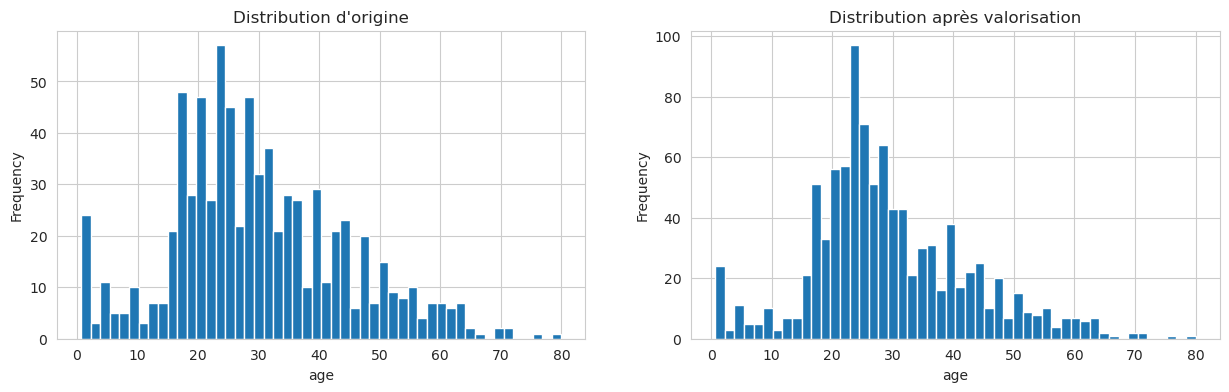

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
X2_train["age"].plot(kind="hist", bins=50, ax=ax1)
ax1.set_title("Distribution d'origine")
ax1.set_xlabel("age")
impute_age(X2_train, mean_ages_class, std_ages_class).plot(kind="hist", bins=50, ax=ax2)
ax2.set_title("Distribution après valorisation")
ax2.set_xlabel("age");

### Valorisation — la fonction complète

**On rassemble maintenant toutes nos stratégies d'imputation** dans une seule fonction qui prend un DataFrame et en retourne une version sans NaN.

> **Pourquoi une fonction réutilisable ?** Parce qu'on aura besoin d'appliquer **exactement les mêmes transformations** au train **et** au test. Une fonction qui prend le DataFrame en paramètre garantit qu'on ne se trompe pas.
>
> **⚠️ Piège à éviter :** les statistiques d'imputation (moyennes par classe, valeur la plus fréquente pour `embarked`) doivent être calculées **sur le train uniquement** et **passées en paramètres** à la fonction pour s'appliquer au test. Sinon, on calcule des stats sur le test et on fuite de l'information.

In [21]:
def impute_null_values(X_df, mean_ages, std_ages):
    X_df["embarked"] = impute_embarked(X_df)
    X_df["fare"] = impute_fare(X_df)
    X_df["age"] = impute_age(X_df, mean_ages, std_ages)
    return X_df

impute_null_values(X2_train.copy(), mean_ages_class, std_ages_class).head()

,pclass,sex,age,sibsp,parch,fare,embarked
3,1.0,male,30.000000,1.0,2.0,151.5500,S
798,3.0,male,26.691669,0.0,0.0,7.0500,S
38,1.0,male,41.000000,0.0,0.0,30.5000,S
367,2.0,male,52.000000,0.0,0.0,13.5000,S
803,3.0,male,26.000000,0.0,0.0,7.8792,Q


## Numérisation des variables catégorielles

**Dernière étape avant l'entraînement :** transformer `sex` et `embarked` (qui sont du texte) en nombres.

On utilise `pd.get_dummies()` (équivalent de `OneHotEncoder` pour pandas) avec `drop_first=True` pour **éviter la colinéarité** :

- `sex ∈ {male, female}` → une seule colonne `sex_male` (0 ou 1) suffit. Pas besoin d'une colonne `sex_female` redondante.
- `embarked ∈ {S, C, Q}` → deux colonnes `embarked_C` et `embarked_Q` suffisent. La 3ème est implicite (si les deux autres sont à 0, c'est `S`).

> **Pourquoi `drop_first=True` ?** Parce que dans une régression linéaire ou logistique, avoir $n$ colonnes one-hot linéairement dépendantes (leur somme = 1) crée une **colinéarité parfaite** qui déstabilise le modèle. En supprimant une colonne par variable, on casse cette dépendance sans perdre d'information.

In [22]:
def convert_categorical(X_df, cols):
    one_hot_encoded = pd.get_dummies(X_df[cols], drop_first=True)
    return X_df.join(one_hot_encoded).drop(cols, axis=1)

convert_categorical(X2_train.copy(), ["sex", "embarked"]).info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 3 to 1117
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      981 non-null    float64
 1   age         771 non-null    float64
 2   sibsp       981 non-null    float64
 3   parch       981 non-null    float64
 4   fare        980 non-null    float64
 5   sex_male    981 non-null    bool   
 6   embarked_Q  981 non-null    bool   
 7   embarked_S  981 non-null    bool   
dtypes: bool(3), float64(5)
memory usage: 81.1 KB


## Fonction de prétraitement complète

**On peut maintenant enchaîner toutes les transformations** en une seule fonction `process_data()` qui prend un DataFrame brut en entrée et en retourne une version prête pour l'entraînement :

1. Suppression des colonnes inutiles.
2. Imputation de `embarked`, `fare`, `age`.
3. One-hot encoding des variables catégorielles restantes.

> **Note importante :** cette approche « fonction maison » est pédagogiquement utile pour voir **étape par étape** ce qui se passe. **En production**, on préfère un **`Pipeline` scikit-learn** qui encapsule toutes ces étapes dans un objet réutilisable, compatible avec `cross_val_score` et `GridSearchCV`, et qui évite les fuites automatiquement.
>
> On reviendra sur les pipelines dans la suite du cours.

In [23]:
def process_data(X_df, mean_age, std_age, cat_cols):
    X_df = drop_columns(X_df)
    X_df = impute_null_values(X_df, mean_age, std_age)
    return convert_categorical(X_df, cat_cols)

In [24]:
X_train = process_data(X1_train, mean_ages_class, std_ages_class, ["sex", "embarked"])
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 3 to 1117
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      981 non-null    float64
 1   age         981 non-null    float64
 2   sibsp       981 non-null    float64
 3   parch       981 non-null    float64
 4   fare        981 non-null    float64
 5   sex_male    981 non-null    bool   
 6   embarked_Q  981 non-null    bool   
 7   embarked_S  981 non-null    bool   
dtypes: bool(3), float64(5)
memory usage: 81.1 KB


## Apprentissage

**On peut maintenant entraîner nos modèles** sur les données enrichies et comparer à la baseline du notebook précédent (qui utilisait une imputation simple par médiane).

In [25]:
logreg_clf = LogisticRegression(C=0.8, max_iter=1000)

In [26]:
scores = cross_val_score(logreg_clf, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.82828283, 0.76530612, 0.85714286, 0.76530612, 0.73469388,
        0.82653061, 0.78571429, 0.84693878, 0.80612245, 0.83673469]),
 0.8052772624201197,
 0.038674378082799214)

### Autres modèles

**On teste aussi un Random Forest** — un modèle plus puissant et souvent plus tolérant au bruit d'imputation.

> **⚠️ Observation intéressante :** les modèles à base d'arbres (Random Forest, XGBoost) sont **moins sensibles** à la qualité de l'imputation que les modèles linéaires (régression logistique). Pourquoi ? Parce qu'un arbre va juste créer une branche *« age == valeur-imputée ? »* qui regroupe tous les imputés — sans se laisser perturber par l'artefact. Les modèles linéaires, eux, prennent les valeurs « au sérieux » et peuvent être déstabilisés par un pic artificiel.
>
> **Conséquence pratique :** l'imputation intelligente apporte typiquement **plus de gain sur les modèles linéaires** que sur les modèles à base d'arbres. Si tu vises XGBoost comme modèle final, n'investis pas trop de temps sur l'imputation — une médiane suffit souvent.

In [27]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(max_depth=6, random_state=2, n_jobs=-1)
scores = cross_val_score(rf_clf, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.83838384, 0.81632653, 0.89795918, 0.7755102 , 0.74489796,
        0.85714286, 0.80612245, 0.79591837, 0.80612245, 0.81632653]),
 0.8154710368996081,
 0.04025148656639921)

## Conclusion

**Bilan de ce notebook :**

- Pour les deux modèles (régression logistique et Random Forest), on observe une **amélioration** de la justesse moyenne **et** une **réduction de la variabilité** des scores en cross-validation.
- L'écart est **plus marqué pour la régression logistique**, comme prévu (les modèles linéaires sont plus sensibles à la qualité de l'imputation).
- Cela confirme que **comprendre ses données paye** : l'EDA multivariée du chapitre 4 nous a permis de faire des choix d'imputation éclairés, et ces choix se traduisent directement en gain de performance.

## 🎯 Pour résumer — imputation avancée en pratique

### Le principe général

**Une bonne imputation exploite les relations entre variables** pour donner aux valeurs manquantes un sens qui se rapproche de la réalité. Plus on exploite de contexte (autres variables, cible, métier), plus on s'approche de la vraie valeur manquante — au lieu d'une approximation « moyenne-pour-tout-le-monde ».

### Les 5 niveaux d'imputation (du plus simple au plus sophistiqué)

| Niveau | Technique | Quand l'utiliser |
|:---:|---|---|
| **1** | Supprimer les lignes / colonnes | Quand c'est 1-2% et que tu peux te le permettre |
| **2** | Imputer par médiane / mode | Baseline simple, rapide, « suffisante souvent » |
| **3** | **Imputer conditionnellement** (group-by) | Quand tu connais une corrélation entre NaN et autres variables |
| **4** | Imputation itérative (`IterativeImputer`) | Quand plusieurs variables ont des NaN qui se recoupent |
| **5** | KNN imputation, ML dédié (`KNNImputer`) | Petits datasets complexes où la qualité d'imputation compte |

### Les techniques sklearn à connaître

- **`SimpleImputer`** — niveau 2. Rapide, robuste, baseline.
- **`KNNImputer`** — niveau 5. Prend la moyenne des $k$ voisins les plus proches (sur les autres features).
- **`IterativeImputer`** (expérimental) — niveau 4. Modélise chaque colonne avec NaN comme une régression sur les autres, itérativement.

### Les bonnes pratiques

- ✅ **Toujours imputer, jamais supprimer** sauf cas extrêmes (>50% de NaN).
- ✅ **Comprendre pourquoi la valeur manque** (MCAR / MAR / MNAR) avant de choisir une méthode.
- ✅ **Calculer les statistiques d'imputation sur le train uniquement** et les propager au test.
- ✅ **Utiliser `stratify=y`** dans `train_test_split` quand les classes sont déséquilibrées.
- ✅ **Vérifier visuellement** l'effet de l'imputation sur la distribution (histogrammes avant/après).
- ✅ **Ajouter une variable indicatrice `was_missing`** si l'absence elle-même semble prédictive (cas MNAR).
- ✅ **En production, utiliser un `Pipeline` scikit-learn** qui encapsule imputation + encodage + modèle.

### Les pièges à éviter

- ⚠️ **Calculer la médiane sur tout le dataset** → data leakage entre train et test.
- ⚠️ **Imputer avec la médiane sur une variable fortement biaisée par la classe** (comme `age` avec `pclass` ici) → perte d'information.
- ⚠️ **Imputer sans analyser le *pattern* de NaN** → parfois, l'absence elle-même est le signal.
- ⚠️ **Appliquer une fonction d'imputation « maison » au lieu d'un `Pipeline`** → risque de désynchronisation entre train et test, bugs silencieux.

### Le mot de la fin

> **L'imputation, c'est un dialogue avec les données.** Une médiane rapide convient pour 80% des cas. Pour les 20% restants — là où il y a beaucoup de NaN ou où ils encodent une information métier — investir du temps à comprendre *pourquoi* les valeurs manquent et *comment* les corréler aux autres variables peut faire passer un modèle de « correct » à « bon ». Mais attention au rendement décroissant : au-delà d'un certain point, raffiner l'imputation rapporte moins qu'améliorer les features ou changer d'algorithme.